# Particle Filter Wall-Clock Test:

## 1. Supporting Functions:

The `GalieleoEvents` repository calls several scripts. The main driver script to run the generative model is `/tests/mc_gm.jl`. This script includes the file `/src/GalileoEvents.jl` which calls `/src/utils/utils.jl` and `/src/gms/gms.jl`. The utils script calls the `distributions.jl` file which defines probability distributions used later on. It also includes `scene.jl` which creates the ramp. The gms script includes the generative model for the particle filter and the changepoint-model. The normal particle filter code exists in the `/src/gms/mc_gm.jl` file. I suspect that `/src/analysis.jl` has the inference code (need to check through it). 

*I will re-implement all of the required functions within this notebook. We can re-distribute the code as functions later on, but it would be useful to have one source that can run every part properly.*

### 1.1 Import Functions

These packages were added to the relevant conda and julia environments and pre-compiled. This allows quick loading in the jupyter environment. 

In [2]:
using Accessors
using Gen
using Compose
using PhySMC
using PhyBullet
using PyCall
using Parameters
using DocStringExtensions
using Distributions
using LinearAlgebra

pybullet build time: Oct 21 2025 11:20:22


### 1.2 Create a Scene:

This uses the code from `/src/utils/scene.jl`. We create a ramp object and the objects on it. The `ramp()` function achieves this, and has the following function signature:

`ramp(mass_ratio::Float64, obj_frictions::NTuple{2, Float64}, obj_positions::NTuple{2}; slope, ramp_intersection)`

In [7]:
function ramp(mass_ratio::Float64, obj_frictions::NTuple{2, Float64} = (.5, .5), obj_positions::NTuple{2, Float64} = (0.5, 1.5), slope::Float64=2/3, tableRampIntersection::Float64=0.0)
    
    # for debugging
    #client = @pycall pb.connect(pb.GUI)::Int64
    #pb.resetDebugVisualizerCamera(4.5, 0, -40, [0.0, 0.0, 0.0]; physicsClientId=client)

    # Set up the pybullet client and set gravity at -10
    client = @pycall pb.connect(pb.DIRECT)::Int64
    pb.setGravity(0,0,-10; physicsClientId = client)


    # add a table base (setting mass = 0 makes it a static object)
    grey = [0.5, 0.5, 0.5, 1]
    base_dims = [5, 1, 0.75] # in meters
    table_dims = [base_dims[1] + 0.2, base_dims[2] + 0.2, 0.1]  # Width, depth, height
    table_base_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents = base_dims / 2, physicsClientId = client)
    table_base_obj_id = pb.createMultiBody(baseCollisionShapeIndex = table_base_col_id, basePosition = [0,0,-(base_dims[3]+table_dims[3])/2], physicsClientId = client)
    pb.changeDynamics(table_base_obj_id, -1; mass = 0., restitution = 0.9, physicsClientId=client)
    pb.changeVisualShape(table_base_obj_id, -1, rgbaColor=grey, physicsClientId=client)

    # Create the tabletop (a flat box)
    table_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=table_dims/2)
    table_body_id = pb.createMultiBody(baseCollisionShapeIndex=table_col_id, basePosition=[0, 0, -table_dims[3]/2])
    pb.changeDynamics(table_body_id, -1; mass = 0., restitution = 0.9, physicsClientId=client)
    pb.changeVisualShape(table_body_id, -1, rgbaColor=grey.+0.2, physicsClientId=client)

    # Create the four frame-like boxes around the tabletop
    frame_height = 0.25
    frame_thickness = 0.05

    frame_dims = [
        [table_dims[1] + 2 * frame_thickness, frame_thickness, frame_height],  # Longer sides
        [table_dims[1] + 2 * frame_thickness, frame_thickness, frame_height],  # Longer sides
        [frame_thickness, table_dims[2], frame_height],  # Shorter sides
        [frame_thickness, table_dims[2], frame_height]  # Shorter sides
    ]

    frame_positions = [
        [0, table_dims[2] / 2 + frame_thickness / 2, 0],  # Top side
        [0, -table_dims[2] / 2 - frame_thickness / 2, 0],  # Bottom side
        [table_dims[1] / 2 + frame_thickness / 2, 0, 0],  # Right side
        [-table_dims[1] / 2 - frame_thickness / 2, 0, 0]  # Left side
    ]

    for (dims, pos) in zip(frame_dims, frame_positions)
        frame_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=dims/2)::Int64
        frame_obj_id = pb.createMultiBody(baseCollisionShapeIndex=frame_col_id, basePosition=pos)::Int64
        pb.changeVisualShape(frame_obj_id, -1, rgbaColor=grey, physicsClientId=client)
    end

    # add a ramp
    pb.setAdditionalSearchPath("/gpfs/radev/project/yildirim/aa2842/minimum-simulation-capsules")
    ramp_col_id = pb.createCollisionShape(pb.GEOM_MESH, fileName="/assets/ramp.obj", physicsClientId=client, meshScale=[2, base_dims[2], slope*2])
    ramp_position = [-2+tableRampIntersection, -base_dims[2]/2, 0]
    ramp_obj_id = pb.createMultiBody(baseCollisionShapeIndex=ramp_col_id, basePosition=ramp_position, physicsClientId=client)
    pb.changeDynamics(ramp_obj_id, -1; mass=0.0, restitution=0.9, physicsClientId=client)
    pb.changeVisualShape(ramp_obj_id, -1, rgbaColor=[1, 1, 1, 1], physicsClientId=client)

    # add a floor
    floor_col_id = pb.createCollisionShape(pb.GEOM_PLANE, physicsClientId=client)
    floor_obj_id = pb.createMultiBody(baseCollisionShapeIndex=floor_col_id, basePosition=[0,0,-base_dims[3]], physicsClientId=client)
    pb.changeDynamics(floor_obj_id, -1; mass=0.0, restitution=0.9, physicsClientId=client)


    #  add walls
    wall_dims = [[0.1, 8.0, 5.0], [0.1, 8.0, 5.0], [8.0, 0.1, 5.0]] # Width, length, height
    wall_positions = [
        [4.0, 0.0, 1.0],  # Right Wall
        [-4.0, 0.0, 1.0],  # Left Wall
        [0, 4, wall_dims[3][3]/2-base_dims[3]] # Back Wall
    ]
    for (dims, pos) in zip(wall_dims, wall_positions)
        wall_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=dims./2, physicsClientId=client)
        wall_obj_id = pb.createMultiBody(baseCollisionShapeIndex=wall_col_id, basePosition=pos, physicsClientId=client)
        pb.changeDynamics(wall_obj_id, -1; mass=0.0, restitution=0.9, physicsClientId=client)
        pb.changeVisualShape(wall_obj_id, -1, rgbaColor=grey+[0.2, 0.2, 0.2, 0], physicsClientId=client)
    end

    # add an object on the ramp
    obj_ramp_dims = [0.15, 0.3, 0.075]
    theta_radians = -atan(slope)
    orientation = [cos(theta_radians / 2), 0, sin(theta_radians / 2), 0]

    obj_on_ramp_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=obj_ramp_dims/2, physicsClientId=client)
    lift = obj_ramp_dims[3]/2
    position = [
        -2+2*obj_positions[1]+tableRampIntersection+lift*cos(theta_radians),
        0,
        (2-2*obj_positions[1])*slope-lift*sin(theta_radians)
    ]
    obj_on_ramp_obj_id = pb.createMultiBody(baseCollisionShapeIndex=obj_on_ramp_col_id, basePosition=position, baseOrientation=orientation, physicsClientId=client)
    pb.changeDynamics(obj_on_ramp_obj_id, -1; mass=mass_ratio, restitution=0.9, lateralFriction=obj_frictions[1], physicsClientId=client)
    
    # add an object on the table that will collide with the object on the ramp as that one slides down
    obj_on_table_dims = [0.2, 0.2, 0.1]
    obj_on_table_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=obj_on_table_dims/2, physicsClientId=client)
    obj_on_table_obj_id = pb.createMultiBody(baseCollisionShapeIndex=obj_on_table_col_id, basePosition=[2.5*(obj_positions[2]-1), 0, obj_on_table_dims[3]/2], physicsClientId=client)
    pb.changeDynamics(obj_on_table_obj_id, -1; mass=1.0, restitution=0.9, lateralFriction=obj_frictions[2], physicsClientId=client)

    (client, obj_on_ramp_obj_id, obj_on_table_obj_id)
end

ramp (generic function with 5 methods)

In [11]:
# Declare constants and create a scene
mass_ratio = 2.0
obj_frictions = (0.3, 0.3)
obj_positions = (0.5, 1.5)

client, obj_1, obj_2 = ramp(mass_ratio, obj_frictions, obj_positions)

(1, 6, 7)

In [12]:
# create PhySMC and PhyBullet objects
sim = BulletSim(; client=client)
obj_r = RigidBody(obj_1)           # ramp obj
obj_t = RigidBody(obj_2)           # table obj

# get an initial state (to be overwritten in the prior function)
init_state = BulletState(sim, [obj_r, obj_t]);

In [13]:
next_state = PhySMC.step(sim, init_state);

### 1.3 Likelihood: Physics Forward Step Function

In [21]:
?RigidBodyLatents.data

`RigidBodyLatents` has fields `data`.


In [22]:
@gen function observe(state::RigidBodyState)
    position ~ broadcasted_normal(state.position, 0.05)
    return position
end;

@gen function drift_object(ls::RigidBodyLatents, drift_std::Float64)
    prev_mass = ls.data.mass
    mass ~ trunc_norm(prev_mass, drift_std, 0.0, Inf)
    return update_latents(ls, mass)
end

@gen function drift_step(prev::BulletState, drift_std::Float64)
    obj1 ~ drift_object(prev.latents[1], drift_std)
    obj2 = update_latents(prev.latents[2], 1.0)
    new_latents = [obj1, obj2]
    new_state = Accessors.setproperties(prev; latents=new_latents)
    return new_state
end

@gen function drift_physics_step(t::Int, prev::BulletState, sim::BulletSim, drift_std::Float64)
    drifted_state ~ drift_step(prev, drift_std)
    next_state = PhySMC.step(sim, drifted_state)
    positions ~ Gen.Map(observe)(next_state.kinematics)
    return next_state
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Int64, BulletState, BulletSim, Float64], false, Union{Nothing, Some{Any}}[nothing, nothing, nothing, nothing], var"##drift_physics_step#315", Bool[0, 0, 0, 0], false)

In [23]:
next_next_state = drift_physics_step(3, next_state, sim, 0.1);

Let's look at some velocities of these states to see how the physics function is evolving the kinematics of the scene. Here we show linear velocities for the object on the ramp. 

In [24]:
init_state.kinematics[1].linear_vel

3-element StaticArraysCore.SVector{3, Float64} with indices SOneTo(3):
 0.0
 0.0
 0.0

In [25]:
next_state.kinematics[1].linear_vel

3-element StaticArraysCore.SVector{3, Float64} with indices SOneTo(3):
  0.09981634525530923
  0.0005410677261925283
 -0.0024687284742010013

In [10]:
next_next_state.kinematics[1].linear_vel

3-element StaticArraysCore.SVector{3, Float64} with indices SOneTo(3):
  0.16642128086164254
  0.00038038621464811317
 -0.0687174865071591

### 1.4 Prior Function

In [34]:
function update_latents(ls::RigidBodyLatents, mass::Float64)
    RigidBodyLatents(setproperties(ls.data; mass=mass))
end;

@gen function sample_object(ls::RigidBodyLatents)
    mass ~ gamma(1.2, 10.)
    new_latents = update_latents(ls, mass)
    return new_latents
end;

@gen function prior(old_latents::Vector{BulletElemLatents})
    # Sample latents for objects...
    obj1 ~ sample_object(old_latents[1])
    obj2 = update_latents(old_latents[2], 1.0)
    
    return BulletElemLatents[obj1, obj2]
end;

In [20]:
?BulletState.latents

`BulletState` has fields `elements`, `latents`, and `kinematics`.


In [23]:
prior(init_state.latents)

2-element Vector{BulletElemLatents}:
 RigidBodyLatents((mass = 3.0000525237552944, lateralFriction = 0.3, restitution = 0.9, rollingFriction = 0.0, spinningFriction = 0.0, contactDamping = -1.0, contactStiffness = -1.0, collisionMargin = 0.001))
 RigidBodyLatents((mass = 1.0, lateralFriction = 0.3, restitution = 0.9, rollingFriction = 0.0, spinningFriction = 0.0, contactDamping = -1.0, contactStiffness = -1.0, collisionMargin = 0.001))

### 1.5 Generative Model

In [35]:
@gen function model(T::Int, sim::BulletSim, template::BulletState)
    # distribution over mass and restitution for objects from the prior
    latents ~ prior(template.latents)
    init_state = Accessors.setproperties(template; latents=latents)
    # simulate `T` timesteps; kind of like a cool for-loop
    states ~ Gen.Unfold(drift_physics_step)(T, init_state, sim)
    return states
end;

In [36]:
gargs = (60, # number of steps (total duration 1s)
         sim,
         init_state);

trace, _ = Gen.generate(model, gargs);

In [43]:
get_choices(trace)

│
├── :latents
│   │
│   └── :obj1
│       │
│       └── :mass : 7.104672928481192
│
└── :states
    │
    ├── 1
    │   │
    │   └── :positions
    │       │
    │       ├── 1
    │       │   │
    │       │   └── :position : [-1.0173922227883243, -0.016649227075231508, 0.7387719205007481]
    │       │
    │       └── 2
    │           │
    │           └── :position : [1.2296795840295554, -0.04652163276543974, 0.06519467245696775]
    │
    ├── 2
    │   │
    │   └── :positions
    │       │
    │       ├── 1
    │       │   │
    │       │   └── :position : [-0.9520634683611182, -0.05930821471612718, 0.6297167195316585]
    │       │
    │       └── 2
    │           │
    │           └── :position : [1.2867534810636092, -0.0659695145980724, 0.07162303359609185]
    │
    ├── 3
    │   │
    │   └── :positions
    │       │
    │       ├── 1
    │       │   │
    │       │   └── :position : [-0.9353385666927585, 0.0022060403911258004, 0.7138559068431466]
    │       │
    │      

### 1.6 Inference via Particle Filter

In [38]:
"""
A truncated normal distribution for random-walk proposals.
"""
struct TruncNorm <: Gen.Distribution{Float64} end

const trunc_norm = TruncNorm()

function Gen.random(::TruncNorm, mu::U, noise::T, low::T, high::T) where {U<:Real,T<:Real}
    d = Distributions.Truncated(Distributions.Normal(mu, noise), low, high)
    return Distributions.rand(d)
end

function Gen.logpdf(::TruncNorm, x::Float64, mu::U, noise::T, low::T, high::T) where {U<:Real,T<:Real}
    d = Distributions.Truncated(Distributions.Normal(mu, noise), low, high)
    return Distributions.logpdf(d, x)
end

In [41]:
"""
This proposal function implements a random walk for the ramp object's mass.

The proposal is truncated so the sampled mass stays physically valid.
"""
@gen function drift_proposal(tr::Gen.Trace, t::Int)
    choices = get_choices(tr)
    prev_mass = choices[:states => t => :drift => :obj1 => :mass]
    mass = {:states => t => :drift => :obj1 => :mass} ~ trunc_norm(prev_mass, 0.25, 0.0, Inf)
    return mass
end

@gen function proposal(tr::Gen.Trace)
    choices = get_choices(tr)

    # Only obj1 mass is random in the prior
    prev_mass = choices[:latents => :obj1 => :mass]

    mass = {:latents => :obj1 => :mass} ~ trunc_norm(prev_mass, 1.0, 0.0, Inf)

    return mass
end

"""
    inference_procedure

Performs particle filter inference with MH rejuvenation.
`gm_args` should be `(T, sim, template)`.
`obs` should be a vector of ChoiceMaps, one per time step.
"""
function inference_procedure(gm_args::Tuple,
                             obs::Vector{Gen.ChoiceMap},
                             particles::Int=20,
                             rejuv_moves::Int=1)

    # model arguments are (T, sim, template), and only T changes online
    get_args(t) = (t, gm_args[2:3]...)

    # initialize particle filter at t = 0
    state = Gen.initialize_particle_filter(model, get_args(0), EmptyChoiceMap(), particles)

    # only the first argument (T) changes from step to step
    argdiffs = (UnknownChange(), NoChange(), NoChange())

    # increment through each observation step
    for (t, o) in enumerate(obs)
        # STEP 1: update with next observation
        Gen.particle_filter_step!(state, get_args(t), argdiffs, o)

        # STEP 2: resample if ESS gets too low
        Gen.maybe_resample!(state, ess_threshold=particles / 2)

        # STEP 3: rejuvenation moves
        for i = 1:particles, s = 1:rejuv_moves
            state.traces[i], _ = mh(state.traces[i], proposal, ())
        end
    end

    # return an unweighted sample of posterior traces
    return Gen.sample_unweighted_traces(state, particles)
end;

In [65]:
function make_observations(observed_positions)
    T = length(observed_positions)
    obs = Vector{Gen.ChoiceMap}(undef, T)

    for t in 1:T
        cm = Gen.choicemap()
        cm[:states => t => :positions => 1 => :position] = observed_positions[t][1]
        cm[:states => t => :positions => 2 => :position] = observed_positions[t][2]

        obs[t] = cm
    end

    return obs
end;

In [47]:
function extract_masses(traces)
    [get_choices(tr)[:latents => :obj1 => :mass] for tr in traces]
end

function summarize_masses(traces)
    ms = extract_masses(traces)
    return (
        mean = mean(ms),
        std = std(ms),
        min = minimum(ms),
        max = maximum(ms),
        masses = ms
    )
end;

In [51]:
function observations_from_trace(tr::Gen.Trace)
    choices = get_choices(tr)
    T = get_args(tr)[1]
    out = Vector{Any}(undef, T)

    for t in 1:T
        p1 = choices[:states => t => :positions => 1 => :position]
        p2 = choices[:states => t => :positions => 2 => :position]
        out[t] = [p1, p2]
    end

    return out
end;

In [56]:
function run_smoke_test(T::Int, sim, template; particles=20, rejuv_moves=1)
    tr, = Gen.generate(model, (T, sim, template))
    observed_positions = observations_from_trace(tr)
    obs = make_observations(observed_positions)

    traces = inference_procedure((T, sim, template), obs, particles, rejuv_moves)

    return (true_trace=tr,
            observed_positions=observed_positions,
            obs=obs,
            posterior_traces=traces,
            summary=summarize_masses(traces))
end

run_smoke_test (generic function with 1 method)

In [59]:
T = 10
result = run_smoke_test(T, sim, init_state; particles=30, rejuv_moves=2)
result.summary

(mean = 11.39658634278168, std = 10.181236383621382, min = 1.5644755535443662, max = 39.219768306916066, masses = [5.50572643432403, 6.25290837606671, 10.514379356290226, 10.514379356290226, 8.935726074914216, 6.25290837606671, 5.50572643432403, 39.219768306916066, 3.7248140165270582, 8.076696145122087  …  3.235558320673457, 3.301353616699599, 12.45931238844771, 3.7248140165270582, 23.558656800537957, 3.301353616699599, 27.426433108248215, 3.301353616699599, 3.3753249573615856, 12.45931238844771])

In [63]:
true_mass = get_choices(result.true_trace)[:latents => :obj1 => :mass]

2.872612786469206

In [66]:
posterior_masses = result.summary.masses

30-element Vector{Float64}:
  5.50572643432403
  6.25290837606671
 10.514379356290226
 10.514379356290226
  8.935726074914216
  6.25290837606671
  5.50572643432403
 39.219768306916066
  3.7248140165270582
  8.076696145122087
  1.5644755535443662
 12.45931238844771
 12.45931238844771
  ⋮
 19.238064231743774
  8.935726074914216
  3.235558320673457
  3.301353616699599
 12.45931238844771
  3.7248140165270582
 23.558656800537957
  3.301353616699599
 27.426433108248215
  3.301353616699599
  3.3753249573615856
 12.45931238844771

In [67]:
using Gen
using Distributions
using Statistics
using Plots

################################################################################
# Helpers
################################################################################

function extract_masses(traces)
    [get_choices(tr)[:latents => :obj1 => :mass] for tr in traces]
end

function summarize_trace_set(traces)
    ms = extract_masses(traces)
    return (
        mean = mean(ms),
        std = std(ms),
        q25 = quantile(ms, 0.25),
        q75 = quantile(ms, 0.75),
        q05 = quantile(ms, 0.05),
        q95 = quantile(ms, 0.95),
        masses = ms
    )
end

################################################################################
# Sequential inference with stored history
################################################################################

function inference_with_history(gm_args::Tuple,
                                obs::Vector{Gen.ChoiceMap},
                                particles::Int=20,
                                rejuv_moves::Int=1)

    get_args(t) = (t, gm_args[2:3]...)

    state = Gen.initialize_particle_filter(model, get_args(0), EmptyChoiceMap(), particles)
    argdiffs = (UnknownChange(), NoChange(), NoChange())

    history = Vector{NamedTuple}(undef, length(obs))

    for (t, o) in enumerate(obs)
        Gen.particle_filter_step!(state, get_args(t), argdiffs, o)
        Gen.maybe_resample!(state, ess_threshold=particles / 2)

        for i in 1:particles, s in 1:rejuv_moves
            state.traces[i], _ = Gen.mh(state.traces[i], proposal, ())
        end

        current_traces = Gen.sample_unweighted_traces(state, particles)
        summ = summarize_trace_set(current_traces)

        history[t] = (
            t = t,
            mean = summ.mean,
            std = summ.std,
            q25 = summ.q25,
            q75 = summ.q75,
            q05 = summ.q05,
            q95 = summ.q95,
            traces = current_traces
        )
    end

    return history
end

################################################################################
# Collision time detection from observed positions
#
# observed_positions[t][1] = obj1 3D position at time t
# observed_positions[t][2] = obj2 3D position at time t
################################################################################

function detect_collision_time(observed_positions; threshold=0.25)
    T = length(observed_positions)
    for t in 1:T
        p1 = observed_positions[t][1]
        p2 = observed_positions[t][2]
        d = norm(p1 .- p2)
        if d < threshold
            return t
        end
    end
    return nothing
end

################################################################################
# Plot
################################################################################

function plot_mass_ratio_history(history; collision_time=nothing, use_quantiles=true)
    ts = [h.t for h in history]
    means = [h.mean for h in history]

    if use_quantiles
        lower = [h.q05 for h in history]
        upper = [h.q95 for h in history]
        yerr = (means .- lower, upper .- means)
    else
        stds = [h.std for h in history]
        yerr = stds
    end

    p = plot(
        ts, means;
        yerror=yerr,
        xlabel="time",
        ylabel="mass ratio",
        label="posterior mean",
        lw=2,
        marker=:circle
    )

    if collision_time !== nothing
        vline!(p, [collision_time], label="collision time", lw=2, ls=:dash)
    end

    return p
end

################################################################################
# Full pipeline for synthetic smoke test
################################################################################

function run_history_smoke_test(T::Int, sim, template; particles=30, rejuv_moves=2)
    true_trace, = Gen.generate(model, (T, sim, template))
    observed_positions = observations_from_trace(true_trace)
    obs = make_observations(observed_positions)

    history = inference_with_history((T, sim, template), obs, particles, rejuv_moves)
    collision_time = detect_collision_time(observed_positions)

    return (
        true_trace = true_trace,
        observed_positions = observed_positions,
        obs = obs,
        history = history,
        collision_time = collision_time
    )
end

run_history_smoke_test (generic function with 1 method)

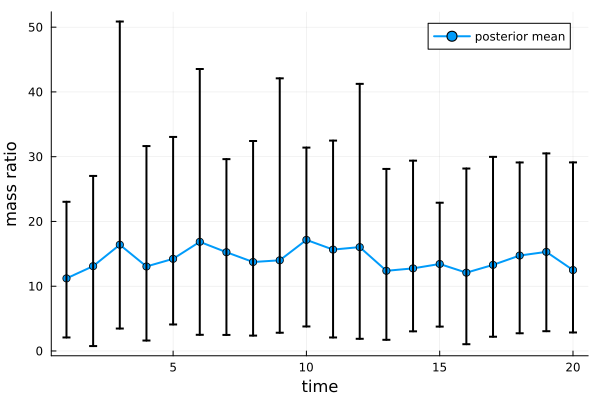

In [70]:
T = 20
res = run_history_smoke_test(T, sim, init_state; particles=30, rejuv_moves=2)

p = plot_mass_ratio_history(res.history; collision_time=res.collision_time, use_quantiles=true)
display(p)

In [26]:
using Gen
using Distributions
using Statistics
using LinearAlgebra
using Plots
using Accessors

################################################################################
# Observation model
################################################################################

@gen function observe(state::RigidBodyState)
    position ~ broadcasted_normal(state.position, 0.05)
    return position
end

################################################################################
# Latent update helpers
################################################################################

function update_latents(ls::RigidBodyLatents, mass::Float64)
    RigidBodyLatents(setproperties(ls.data; mass=mass))
end

################################################################################
# Initial prior 
################################################################################

@gen function sample_object(ls::RigidBodyLatents)
    mass ~ gamma(1.2, 10.0)
    return update_latents(ls, mass)
end

@gen function prior(old_latents::Vector{BulletElemLatents})
    obj1 ~ sample_object(old_latents[1])
    obj2 = update_latents(old_latents[2], 1.0)
    return BulletElemLatents[obj1, obj2]
end

################################################################################
# Truncated normal 
################################################################################

struct TruncNorm <: Gen.Distribution{Float64} end
const trunc_norm = TruncNorm()

function Gen.random(::TruncNorm, mu::U, noise::T, low::T, high::T) where {U<:Real,T<:Real}
    d = Distributions.Truncated(Distributions.Normal(mu, noise), low, high)
    return Distributions.rand(d)
end

function Gen.logpdf(::TruncNorm, x::Float64, mu::U, noise::T, low::T, high::T) where {U<:Real,T<:Real}
    d = Distributions.Truncated(Distributions.Normal(mu, noise), low, high)
    return Distributions.logpdf(d, x)
end

################################################################################
# Drift model 
################################################################################

"""
Drift the unknown object's mass around its previous value.
"""
@gen function drift_object(ls::RigidBodyLatents, drift_std::Float64)
    prev_mass = ls.data.mass
    mass ~ trunc_norm(prev_mass, drift_std, 0.0, Inf) #TODO give an upper bound
    return update_latents(ls, mass)
end

"""
Apply latent drift before the next physics step.
Only obj1 drifts; obj2 is kept fixed at mass=1.
"""
@gen function drift_step(prev::BulletState, drift_std::Float64)
    obj1 ~ drift_object(prev.latents[1], drift_std)
    obj2 = update_latents(prev.latents[2], 1.0)
    new_latents = BulletElemLatents[obj1, obj2]
    new_state = Accessors.setproperties(prev; latents=new_latents)
    return new_state
end

"""
Drift latents, then run deterministic physics, then get noisy observations.
"""
@gen function drift_physics_step(t::Int, prev::BulletState, sim::BulletSim, drift_std::Float64)
    drift ~ drift_step(prev, drift_std)
    next_state = PhySMC.step(sim, drift)
    positions ~ Gen.Map(observe)(next_state.kinematics)
    return next_state
end

@gen function drift_model(T::Int, sim::BulletSim, template::BulletState, drift_std::Float64)
    latents ~ prior(template.latents)
    init_state = Accessors.setproperties(template; latents=latents)
    states ~ Gen.Unfold(drift_physics_step)(T, init_state, sim, drift_std)
    return states
end

################################################################################
# Observation construction
################################################################################

function make_observations(observed_positions)
    T = length(observed_positions)
    obs = Vector{Gen.ChoiceMap}(undef, T)

    for t in 1:T
        cm = Gen.choicemap()
        cm[:states => t => :positions => 1 => :position] = observed_positions[t][1]
        cm[:states => t => :positions => 2 => :position] = observed_positions[t][2]
        obs[t] = cm
    end

    return obs
end


function observations_from_trace(tr::Gen.Trace)
    choices = get_choices(tr)
    T = get_args(tr)[1]
    out = Vector{Any}(undef, T)

    for t in 1:T
        p1 = choices[:states => t => :positions => 1 => :position]
        p2 = choices[:states => t => :positions => 2 => :position]
        out[t] = [p1, p2]
    end

    return out
end

################################################################################
# Rejuvenation proposal for drift model
################################################################################

"""
MH proposal for the drifted mass at a specific time t.
Address path is:
:states => t => :drift => :obj1 => :mass
"""
@gen function drift_proposal(tr::Gen.Trace, t::Int)
    choices = get_choices(tr)
    prev_mass = choices[:states => t => :drift => :obj1 => :mass]
    mass = {:states => t => :drift => :obj1 => :mass} ~ trunc_norm(prev_mass, 0.25, 0.0, Inf) # TODO upper bound (same as above)
    return mass
end

function drift_inference_procedure(gm_args::Tuple,
                                   obs::Vector{Gen.ChoiceMap},
                                   particles::Int=20,
                                   rejuv_moves::Int=1)

    # gm_args = (T, sim, template, drift_std)
    get_args(t) = (t, gm_args[2:4]...)

    state = Gen.initialize_particle_filter(drift_model, get_args(0), EmptyChoiceMap(), particles)
    argdiffs = (UnknownChange(), NoChange(), NoChange(), NoChange())

    for (t, o) in enumerate(obs)
        Gen.particle_filter_step!(state, get_args(t), argdiffs, o)
        Gen.maybe_resample!(state, ess_threshold=particles / 2)

        for i in 1:particles, s in 1:rejuv_moves
            # state.traces[i], _ = Gen.mh(state.traces[i], drift_proposal, (t,)) # use selection instead of a proposal function; 
            state.traces[i], _ = Gen.mh(state.traces[i], Gen.select(:states => t => :drift => :obj1 => :mass)) # use selection instead of a proposal function;
        end
    end

    return Gen.sample_unweighted_traces(state, particles)
end

################################################################################
# Posterior summaries over time
################################################################################

function extract_current_drift_mass(tr::Gen.Trace, t::Int)
    get_choices(tr)[:states => t => :drift => :obj1 => :mass]
end

function summarize_drift_masses(traces, t::Int)
    ms = [extract_current_drift_mass(tr, t) for tr in traces]
    return (
        mean = mean(ms),
        std = std(ms),
        q05 = quantile(ms, 0.05),
        q25 = quantile(ms, 0.25),
        q75 = quantile(ms, 0.75),
        q95 = quantile(ms, 0.95),
        masses = ms
    )
end

function drift_inference_with_history(gm_args::Tuple,
                                      obs::Vector{Gen.ChoiceMap},
                                      particles::Int=20,
                                      rejuv_moves::Int=1)

    get_args(t) = (t, gm_args[2:4]...)

    state = Gen.initialize_particle_filter(drift_model, get_args(0), EmptyChoiceMap(), particles)
    argdiffs = (UnknownChange(), NoChange(), NoChange(), NoChange())

    history = Vector{NamedTuple}(undef, length(obs))

    for (t, o) in enumerate(obs)
        Gen.particle_filter_step!(state, get_args(t), argdiffs, o)
        Gen.maybe_resample!(state, ess_threshold=particles / 2)

        for i in 1:particles, s in 1:rejuv_moves
            state.traces[i], _ = Gen.mh(state.traces[i], drift_proposal, (t,))
        end

        current_traces = Gen.sample_unweighted_traces(state, particles)
        summ = summarize_drift_masses(current_traces, t)

        history[t] = (
            t = t,
            mean = summ.mean,
            std = summ.std,
            q05 = summ.q05,
            q25 = summ.q25,
            q75 = summ.q75,
            q95 = summ.q95,
            traces = current_traces
        )
    end

    return history
end

################################################################################
# Collision detection and plotting
################################################################################

function detect_collision_time(observed_positions; threshold=0.25)
    T = length(observed_positions)
    for t in 1:T
        p1 = observed_positions[t][1]
        p2 = observed_positions[t][2]
        d = sqrt(sum((p1 .- p2).^2))
        if d < threshold
            return t
        end
    end
    return nothing
end

function plot_mass_ratio_history(history; collision_time=nothing, use_quantiles=true)
    ts = [h.t for h in history]
    means = [h.mean for h in history]

    if use_quantiles
        lower = [h.q05 for h in history]
        upper = [h.q95 for h in history]
        yerr = (means .- lower, upper .- means)
    else
        stds = [h.std for h in history]
        yerr = stds
    end

    p = plot(
        ts, means;
        yerror=yerr,
        xlabel="time",
        ylabel="mass ratio",
        label="posterior mean",
        lw=2,
        marker=:circle
    )

    if collision_time !== nothing
        vline!(p, [collision_time], label="collision time", lw=2, ls=:dash)
    end

    return p
end

################################################################################
# Synthetic smoke test for drift model
################################################################################

function run_drift_smoke_test(T::Int, sim, template, drift_std::Float64; particles=30, rejuv_moves=2)
    true_trace, = Gen.generate(drift_model, (T, sim, template, drift_std))
    observed_positions = observations_from_trace(true_trace)
    obs = make_observations(observed_positions)

    history = drift_inference_with_history((T, sim, template, drift_std), obs, particles, rejuv_moves)
    collision_time = detect_collision_time(observed_positions)

    return (
        true_trace = true_trace,
        observed_positions = observed_positions,
        obs = obs,
        history = history,
        collision_time = collision_time
    )
end

run_drift_smoke_test (generic function with 1 method)

In [27]:
mass_ratio = 2.0
obj_frictions = (0.3, 0.3)
obj_positions = (0.5, 1.5)

client, obj_1, obj_2 = ramp(mass_ratio, obj_frictions, obj_positions)

# create PhySMC and PhyBullet objects
sim = BulletSim(; client=client)
obj_r = RigidBody(obj_1)           # ramp obj
obj_t = RigidBody(obj_2)           # table obj

# get an initial state (to be overwritten in the prior function)
init_state = BulletState(sim, [obj_r, obj_t]);

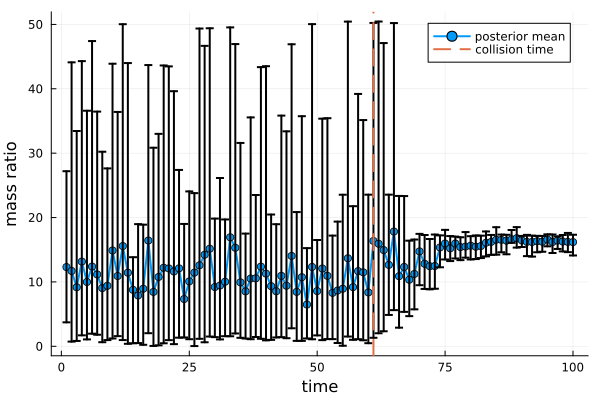

In [29]:
T = 100
drift_std = 0.15

res = run_drift_smoke_test(T, sim, init_state, drift_std; particles=30, rejuv_moves=2)

p = plot_mass_ratio_history(res.history; collision_time=res.collision_time, use_quantiles=true)
display(p)